In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#submission folder
main_folder = Path("Baliti_Ocean Modelling Exercises")
figures_folder = main_folder / "Figures"

figures_folder.mkdir(parents=True, exist_ok=True)

In [3]:
# Parameters
k = 0.1
P0 = 0.1
N0 = 5.0

t = np.linspace(0, 20, 400)
total = P0 + N0

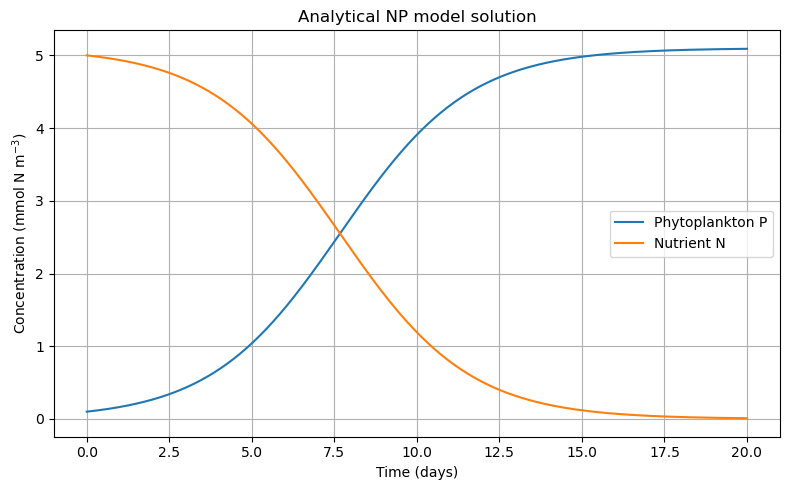

In [4]:
# Analytical solution
P = (P0 * total) / (P0 + N0 * np.exp(-k * total * t))
N = total - P

plt.figure(figsize=(8, 5))
plt.plot(t, P, label='Phytoplankton P')
plt.plot(t, N, label='Nutrient N')
plt.xlabel('Time (days)')
plt.ylabel('Concentration (mmol N m$^{-3}$)')
plt.title('Analytical NP model solution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex2_np_analytical.png', dpi=200)
plt.show()

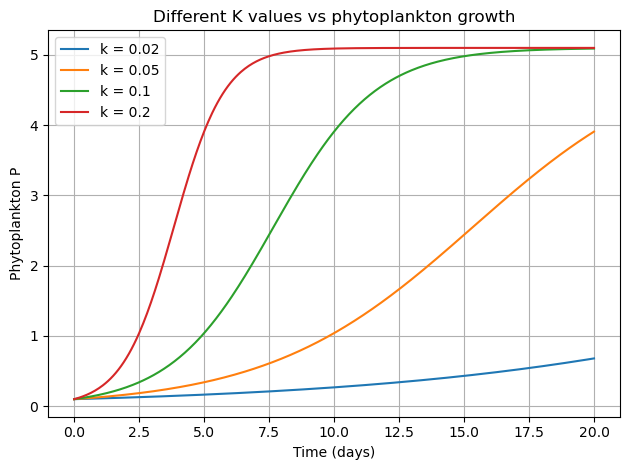

In [5]:
#changing uptake parameter k
for kval in [0.02, 0.05, 0.1, 0.2]:
    Pk = (P0 * total) / (P0 + N0 * np.exp(-kval * total * t))
    plt.plot(t, Pk, label=f'k = {kval}')

plt.xlabel('Time (days)')
plt.ylabel('Phytoplankton P')
plt.title('Different K values vs phytoplankton growth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder/'ex2_k_sensitivity.png', dpi=200)
plt.show()

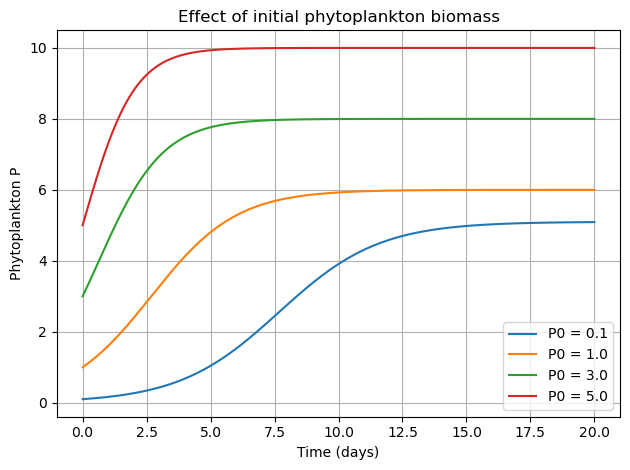

In [6]:
#initial phytoplankton biomass
for P0_test in [0.1, 1.0, 3.0, 5.0]:
    total_test = P0_test + N0
    P_test = (P0_test * total_test) / (P0_test + N0 * np.exp(-k * total_test * t))
    plt.plot(t, P_test, label=f'P0 = {P0_test}')

plt.xlabel('Time (days)')
plt.ylabel('Phytoplankton P')
plt.title('Effect of initial phytoplankton biomass')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder/'ex2_initial_P_sensitivity.png', dpi=200)
plt.show()

## Answers

1. The nutrient and phytoplankton curves have identical shape because as N decreases, P increases by the same amount.

2. Changing the uptake parameter changes the time it takes for the curve to reach equilibrium, for example when k = 0.02, phytoplankton grows slowly and does not reach the maximum within 20 days but when k = 0.2, phytoplankton grows much faster and reaches the equilirium early. So increasing k makes nutrient consumption happen faster.

3. When the initial phytoplankton biomass is higher, the model starts with more phytoplankton already present, N is consumed faster from the beginning, so the phytoplankton curve rises more quickly and reaches the equilibrium faster.